# STATE HP sweep on PBMC — MI curves

One line per HP trial, x = quality (log), y = MI per signal.

In [17]:
# Gather results by walking hp_tunning/ following the layout written by
# 2026-04-16_14-43_compute_state_hparam_sweep_pbmc.py:
#   hp_tunning/hp_trial_XX.yaml                      -> per-trial HP config
#   hp_tunning/hp_trial_XX/sz<size>/q<quality>/      -> per-run artifacts
#       MI/<seed>/Y_<signal>_<quality>/lmi_mutual_information.txt
import re
from pathlib import Path

import pandas as pd
import yaml

OUTPUT_DIR = Path('/home/igor/noise_scaling/data/other/hp_tunning')
MI_SEED = 42  # first seed emitted by latentmi

def _parse_quality(tag: str) -> float:
    # 'q0_0012346' -> 0.0012346, 'q1_0' -> 1.0
    return float(tag[1:].replace('_', '.', 1))

def _parse_size(tag: str) -> int:
    return int(tag[2:])

rows = []
for yaml_path in sorted(OUTPUT_DIR.glob('hp_trial_*.yaml')):
    doc = yaml.safe_load(yaml_path.read_text()) or {}
    cfg = doc.get('config', {}) or {}
    trial_id = int(cfg.get('trial_id', int(re.search(r'\d+', yaml_path.stem).group())))
    trial_name = f'hp_trial_{trial_id:02d}'
    trial_dir = OUTPUT_DIR / trial_name
    if not trial_dir.is_dir():
        continue
    for size_dir in sorted(p for p in trial_dir.iterdir() if p.is_dir() and p.name.startswith('sz')):
        for q_dir in sorted(p for p in size_dir.iterdir() if p.is_dir() and p.name.startswith('q')):
            row = {**cfg, 'trial_id': trial_id, 'trial_name': trial_name,
                   'size': _parse_size(size_dir.name), 'quality': _parse_quality(q_dir.name)}
            mi_root = q_dir / 'MI' / str(MI_SEED)
            if mi_root.is_dir():
                for sig_dir in filter(Path.is_dir, mi_root.iterdir()):
                    m = re.match(r'Y_(.+)_[^_]+$', sig_dir.name)
                    signal = m.group(1) if m else sig_dir.name
                    f = sig_dir / 'lmi_mutual_information.txt'
                    if f.exists():
                        try: row[f'mi_{signal}'] = float(f.read_text().strip())
                        except ValueError: pass
            rows.append(row)

df = pd.DataFrame(rows)
mi_cols_found = [c for c in df.columns if c.startswith('mi_')]
print(f'{len(df)} rows across {df["trial_id"].nunique() if len(df) else 0} trials  '
      f'mi_cols={mi_cols_found}')
df

,trial_id,pad_length,dropout,batch_size,max_lr,weight_decay,trial_name,size,quality,mi_celltype.l3,mi_protein_counts
0,0,2048,0.0,32,0.001,0.0010,hp_trial_00,100000,0.001235,-0.01312,-0.01083
1,0,2048,0.0,32,0.001,0.0010,hp_trial_00,100000,0.002598,NaN,NaN
2,0,2048,0.0,32,0.001,0.0010,hp_trial_00,100000,0.005468,NaN,NaN
3,0,2048,0.0,32,0.001,0.0010,hp_trial_00,100000,0.011508,NaN,NaN
4,0,2048,0.0,32,0.001,0.0010,hp_trial_00,100000,0.024220,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
155,15,2048,0.1,128,0.001,0.0001,hp_trial_15,100000,0.050973,NaN,NaN
156,15,2048,0.1,128,0.001,0.0001,hp_trial_15,100000,0.107277,NaN,NaN
157,15,2048,0.1,128,0.001,0.0001,hp_trial_15,100000,0.225772,NaN,NaN
158,15,2048,0.1,128,0.001,0.0001,hp_trial_15,100000,0.475155,NaN,NaN


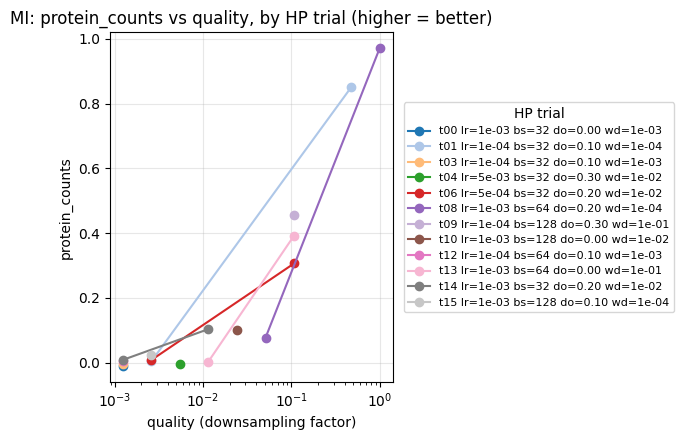

In [18]:
# MI curve for protein_counts only: one line per HP trial, x = quality (log), y = MI.
import matplotlib.pyplot as plt

mi_col = 'mi_protein_counts'
if mi_col not in df.columns:
    print(f'{mi_col} not found — nothing to plot.')
else:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    trial_ids = sorted(df['trial_id'].unique())
    cmap = plt.get_cmap('tab20' if len(trial_ids) > 10 else 'tab10')

    for i, tid in enumerate(trial_ids):
        sub = df[df['trial_id'] == tid].sort_values('quality')
        sub = sub[sub[mi_col].notna()]
        if sub.empty:
            continue
        cfg = sub.iloc[0]
        label = (f"t{int(tid):02d} "
                 f"lr={cfg['max_lr']:.0e} bs={int(cfg['batch_size'])} "
                 f"do={cfg['dropout']:.2f} wd={cfg['weight_decay']:.0e}")
        ax.plot(sub['quality'].values, sub[mi_col].values,
                marker='o', linewidth=1.5, color=cmap(i % cmap.N), label=label)

    ax.set_xscale('log')
    ax.set_xlabel('quality (downsampling factor)')
    ax.set_ylabel('protein_counts')
    ax.set_title('MI: protein_counts vs quality, by HP trial (higher = better)')
    ax.grid(alpha=0.3)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, title='HP trial')
    plt.tight_layout()
    plt.show()